In [38]:
#install neccesary data
pip install rdatasets

SyntaxError: invalid syntax (3433221765.py, line 2)

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as pyplot

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_wine

from rdatasets import data

### Step 1

In [ ]:
#load the data sets

#1. Wine dataset
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df['target'] = wine_data.target 

wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
#2. Chickwts dataset 
chickwts_df = data("chickwts")
chickwts_df.head()


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [ ]:
#3. USArrests dataset
usarrests_df= data("USArrests")
usarrests_df.head()


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [ ]:
#check the data sets summaries
print("WINE DATASET")
print(wine_df.shape)
print()

print("CHICKWTS DATASET")
print(chickwts_df.shape)
print()

print("USARRESTS DATASET")
print(usarrests_df.shape)

WINE DATASET
(178, 14)

CHICKWTS DATASET
(71, 3)

USARRESTS DATASET
(50, 5)


In [ ]:
#check for missing values
wine_df.isna().sum()
print("Missing values - Wine:\n",wine_df.isna().sum())


Missing values - Wine:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


In [ ]:
print("Missing values - Chickwts:\n", chickwts_df.isna().sum())


Missing values - Chickwts:
 rownames    0
weight      0
feed        0
dtype: int64


In [ ]:
print("\nMissing values - USArrests:\n", usarrests_df.isna().sum())


Missing values - USArrests:
 rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


No missing values were found in eather of the datasets, so no rows needed to be dropped

### Step 2: Wine Data Set k-NN Classification

In [ ]:
# seperate features and target
X = wine_df.drop(columns='target')
y = wine_df['target']

# Split BEFORE scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on training data only and transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (142, 13)
Test shape: (36, 13)


In [51]:
# Confirm target is already numeric (no string labels to encode)
print(y.unique())
print(y.dtype)

[0 1 2]
int64


In [ ]:
#instantiate pca and apply on feature(X)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components retained:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Number of components retained: 10
Explained variance ratio: [0.35792104 0.19270671 0.11019835 0.07272276 0.06721919 0.05131943
 0.04377423 0.02500853 0.0227943  0.01877102]
Total variance explained: 0.9624355601767978


In [44]:
# get the % variance explained by each principal componet(PC), apply on instantiated pca component
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f'PC{i+1}: {ratio:.2%}')

PC1: 35.79%
PC2: 19.27%
PC3: 11.02%
PC4: 7.27%
PC5: 6.72%
PC6: 5.13%
PC7: 4.38%
PC8: 2.50%
PC9: 2.28%
PC10: 1.88%


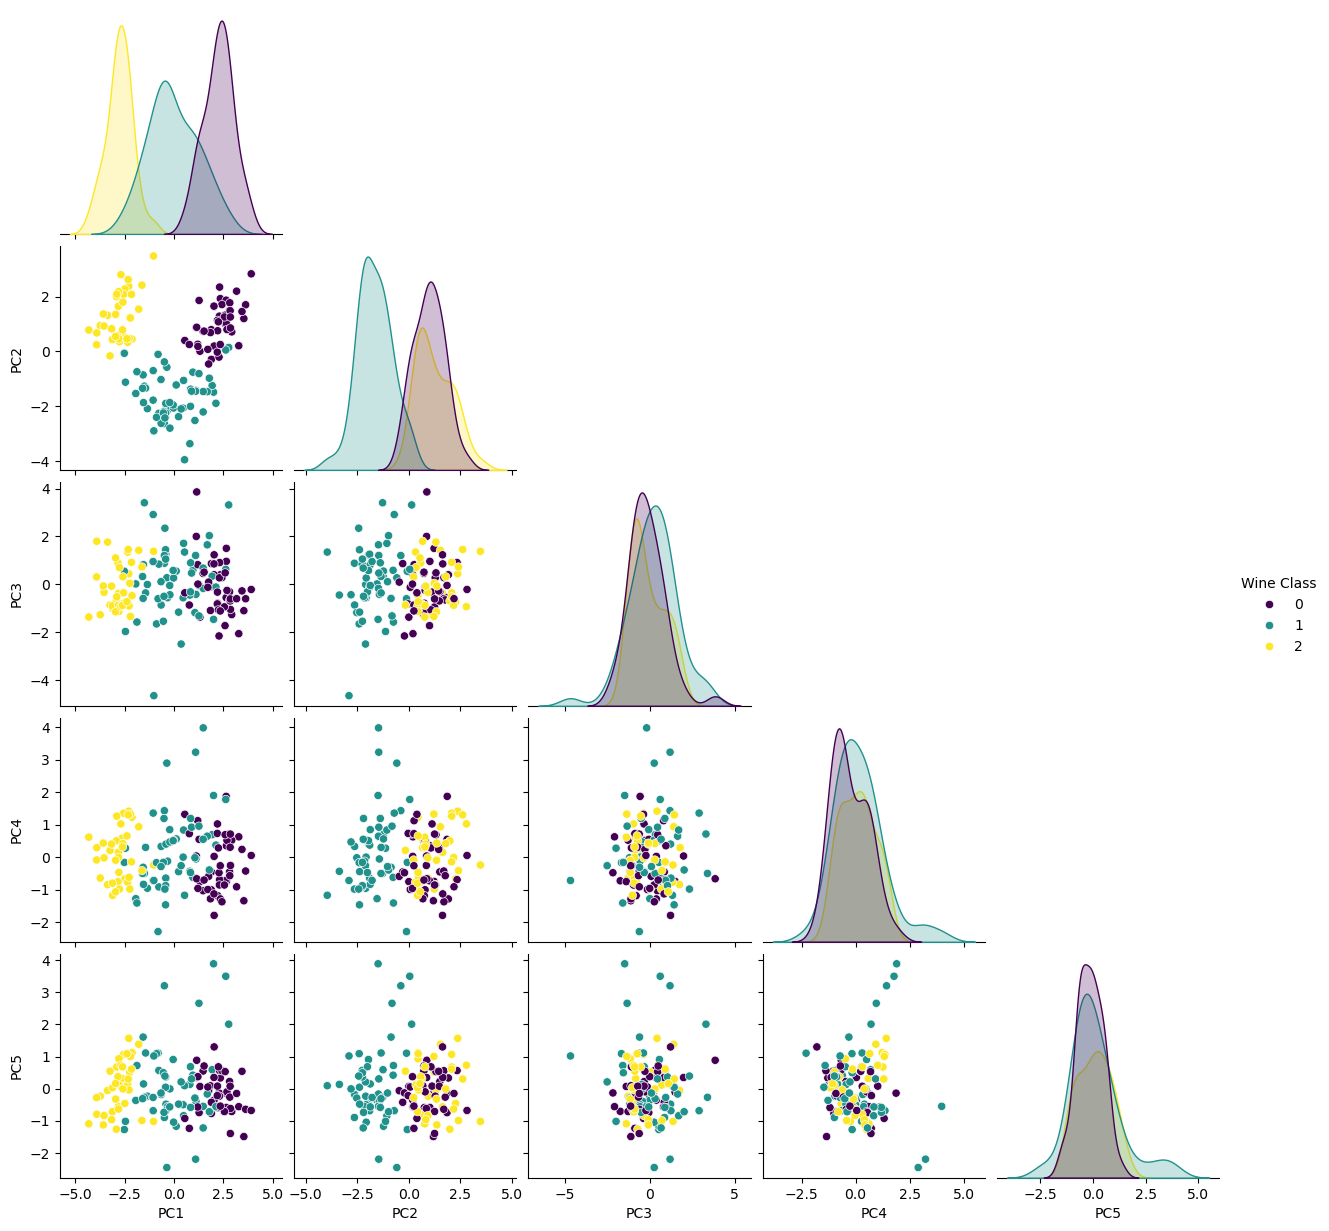

In [46]:
# Build a dataframe with the first 5 PCs + class label
pca_df = pd.DataFrame(X_train_pca[:, :5], columns=[f'PC{i+1}' for i in range(5)])
pca_df['Wine Class'] = y_train.values

# Pairplot across all 5 PCs, colored by class
sns.pairplot(pca_df, hue='Wine Class', palette='viridis', corner=True)

PCA: Retaining 95% of variance required 10 principal components (out of 13 original 
features). PC1 and PC2 alone explained 55% of the variance, but the pairplot across the 
first 5 PCs showed clear separation between the three wine classes, particularly in PC1 
vs PC2 and PC1 vs PC3.

In [49]:
#Grid Search CV
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_pca, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)
print("Best_knn:", grid_search.best_estimator_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 18}
Best cross-validation accuracy: 0.9790640394088669
Best_knn: KNeighborsClassifier(metric='euclidean', n_neighbors=18)


Hyperparameter tuning: GridSearchCV tested k values from 1–20 across three distance metrics (euclidean, manhattan, minkowski). The best parameters were *k=18* with the *euclidean* distance metric, achieving 97.9% cross-validation accuracy.

In [50]:
# Use the best estimator found by GridSearchCV
best_knn = grid_search.best_estimator_

# Predict on test set
y_pred = best_knn.predict(X_test_pca)

# Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



Final evaluation: The tuned k-NN model achieved 100% accuracy on the held-out test set, with perfect precision, recall, and f1-scores across all three wine classes. This strong, consistent performance (test accuracy matching or exceeding CV accuracy) indicates the model generalizes well and is not overfitting.

### Step 3. Chickwts Recommendation System


In [60]:
# Standardize weight data
scaler = StandardScaler()
chickwts_scaled = scaler.fit_transform(chickwts_df[["weight"]])

In [ ]:
# Apply PCA to reduce to 1 principal component
pca = PCA(n_components=1)
chickwts_pca = pca.fit_transform(chickwts_scaled)

In [62]:
# Compute similarity matrix between all chickens based on PC1

similarity_matrix = cosine_similarity(chickwts_pca)

In [63]:
# Function to recommend similar feeds
def recommend_feeds(feed_name, num_recommendations=3):
    # Get the index of the first chicken with this feed type
    feed_index = chickwts_df.index[chickwts_df["feed"] == feed_name].tolist()[0]
    
    # Get similarity scores for this chicken against all others
    similarity_scores = list(enumerate(similarity_matrix[feed_index]))
    
    # Sort by similarity score, highest first
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)
    
    # Skip index 0 (the chicken itself), take the next top N most similar
    recommended_feeds = [chickwts_df.iloc[i]["feed"] for i, score in similarity_scores[1:num_recommendations+1]]
    return recommended_feeds

# Example recommendation
print("Recommended feeds for 'soybean':", recommend_feeds("soybean"))

Recommended feeds for 'soybean': ['horsebean', 'horsebean', 'horsebean']


##### Approach & Interpretation

The weight column was standardized and reduced to 1 principal component via PCA, then cosine similarity was computed between all 71 individual chicken records. The recommend_feeds function takes a feed name, finds the first chicken in the dataset raised on that feed, and returns the feed types of the 3 individual chickens most similar to it in weight.

Result: Recommended feeds for 'soybean' were ['horsebean', 'horsebean', 'horsebean']. This means the first soybean-fed chicken's weight happened to be closest to three horsebean-fed chickens' weights specifically, not that horsebean and soybean are similar feeds overall. Because the comparison is done at the individual chicken level (not averaged per feed type), results can vary depending on which specific chicken is picked to represent a feed type, and may not always reflect the broader trend for that feed category.

### Step 4. USArrests Dataset-Clustering(K-means and GMM)

In [64]:
# Standardize the 4 numeric features so they're on the same scale
scaler = StandardScaler()
usarrests_scaled = scaler.fit_transform(usarrests_df[["Murder", "Assault", "UrbanPop", "Rape"]])

In [ ]:
# Select top 3 crime-related features for clustering
# (Murder, Assault, Rape are all violent crime rates; the core signal for this analysis;
# UrbanPop is a demographic feature, not a crime statistic, so it's dropped here)

usarrests_scaled_df = pd.DataFrame(usarrests_scaled, columns=["Murder", "Assault", "UrbanPop", "Rape"])
usarrests_selected = usarrests_scaled_df[["Murder", "Assault", "Rape"]]

In [66]:
# Apply PCA to reduce the 3 selected features down to 2 principal components

pca = PCA(n_components=2)
usarrests_pca = pca.fit_transform(usarrests_selected)

# Check how much variance is captured by the 2 components
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.7861934  0.15268378]
Total variance explained: 0.9388771782627572


93.9% variance explained with just 2 components (78.6% + 15.3%), which is a strong result. That confirms Murder, Assault, and Rape are highly correlated so PCA compresses them efficiently.

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

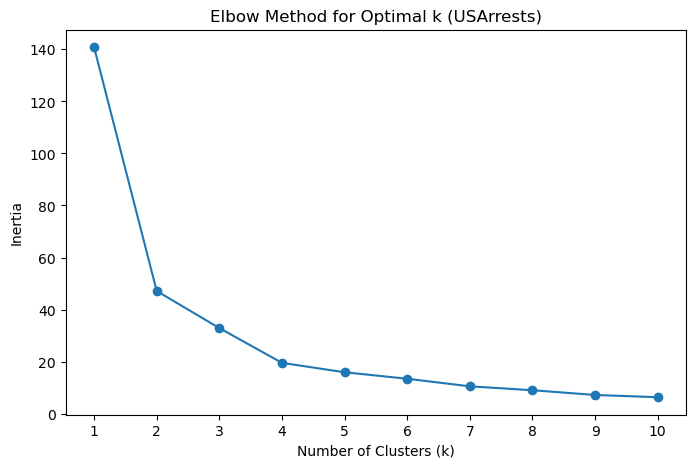

In [67]:
# Compute inertia (within-cluster sum of squares) for k = 1 to 10
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(usarrests_pca)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (USArrests)')
plt.xticks(k_range)
plt.show()

Rather than programmatically selecting the k with the lowest inertia the elbow plot was inspected visually to identify the point of diminishing returns.

The plot shows a sharp drop in inertia from k=1 to k=2, after which the curve flattens significantly, additional clusters beyond k=2 provide little further reduction in inertia. Based on this, *k=2* was selected as the optimal number of clusters.

In [68]:
# Based on the elbow plot
best_k = 2
print(f"Selected number of clusters for K-Means: {best_k}")

Selected number of clusters for K-Means: 2


In [69]:
# Apply K-Means clustering with the chosen number of clusters

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
usarrests_df["KMeans_Cluster"] = kmeans.fit_predict(usarrests_pca)

usarrests_df.head()

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,rownames,Murder,Assault,UrbanPop,Rape,KMeans_Cluster
0,Alabama,13.2,236,58,21.2,1
1,Alaska,10.0,263,48,44.5,1
2,Arizona,8.1,294,80,31.0,1
3,Arkansas,8.8,190,50,19.5,0
4,California,9.0,276,91,40.6,1


K-Means ran successfully: states are now split into 2 clusters, and it makes intuitive sense: Arkansas (lower Murder/Assault/Rape numbers) landed in cluster 0, while Alabama, Alaska, Arizona, California (higher crime stats) are all in cluster 1.

In [70]:
# Hyperparameter tuning for GMM: find best number of clusters using BIC
# (Lower BIC = better balance of model fit vs. complexity)

best_gmm_k = 1
lowest_bic = np.inf

for k in range(1, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(usarrests_pca)
    bic = gmm.bic(usarrests_pca)
    if bic < lowest_bic:
        lowest_bic = bic
        best_gmm_k = k

print(f"Best number of clusters for GMM: {best_gmm_k}")

Best number of clusters for GMM: 2


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [71]:
# Apply GMM clustering with the optimal number of components
gmm = GaussianMixture(n_components=best_gmm_k, random_state=42)
usarrests_df["GMM_Cluster"] = gmm.fit_predict(usarrests_pca)

usarrests_df.head()

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,rownames,Murder,Assault,UrbanPop,Rape,KMeans_Cluster,GMM_Cluster
0,Alabama,13.2,236,58,21.2,1,1
1,Alaska,10.0,263,48,44.5,1,1
2,Arizona,8.1,294,80,31.0,1,1
3,Arkansas,8.8,190,50,19.5,0,0
4,California,9.0,276,91,40.6,1,1


GMM also independently landed on k=2, and even better: K-Means and GMM completely agree on every single row shown (Alabama, Alaska, Arizona, California is cluster 1; Arkansas is cluster 0). That agreement between two different clustering methods is a strong signal that k=2 is a genuinely meaningful split in this data, not just an artifact of one algorithm’s assumptions.

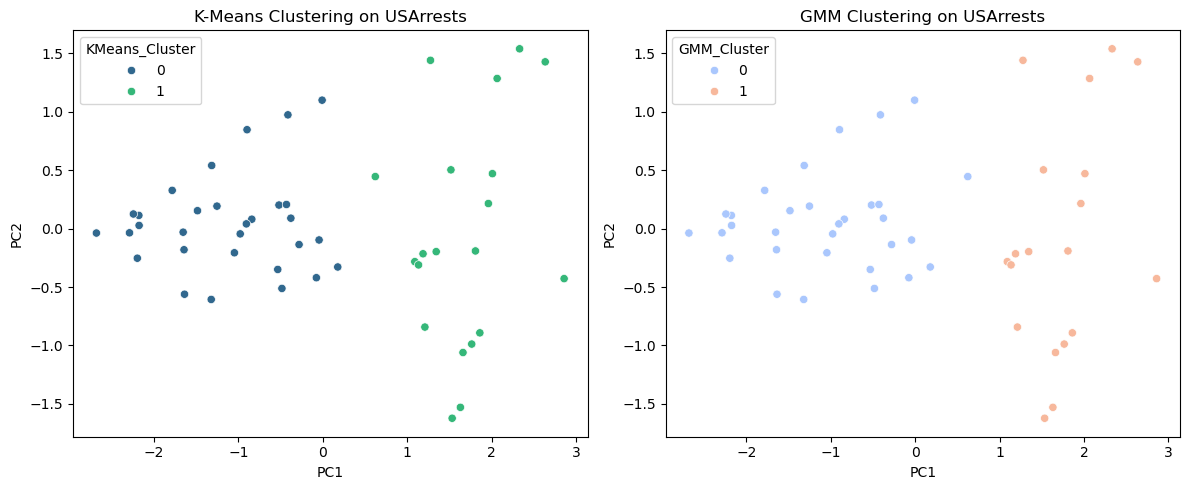

In [72]:
# Visualize K-Means and GMM clustering results side by side
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1], hue=usarrests_df["KMeans_Cluster"], palette="viridis")
plt.title("K-Means Clustering on USArrests")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.subplot(1, 2, 2)
sns.scatterplot(x=usarrests_pca[:, 0], y=usarrests_pca[:, 1], hue=usarrests_df["GMM_Cluster"], palette="coolwarm")
plt.title("GMM Clustering on USArrests")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()

Both plots show the split happens primarily along PC1: states with lower PC1 values cluster together, and states with higher PC1 (further right) form the second cluster. Since PC1 captured 79% of the variance and was built from Murder, Assault, and Rape (all violent crime rates), this strongly suggests PC1 represents overall violent crime rate, and the two clusters represent low-crime vs high-crime states.


##### Clustering Interpretation: USArrests

Both K-Means and GMM identified k=2 as the optimal number of clusters, and largely agree 
on cluster assignments (e.g., Arkansas consistently in cluster 0; Alabama, Alaska, Arizona, 
and California consistently in cluster 1).

Since PC1 explains ~79% of variance and is driven primarily by Murder, Assault, and Rape 
rates, PC1 can be interpreted as an overall "violent crime intensity" score. The two 
clusters likely represent lower violent-crime states vs. higher violent-crime 
states.

K-Means and GMM don't draw the cluster boundary identically,  GMM's high-crime cluster is 
more tightly concentrated toward the highest PC1 values, while K-Means includes a broader 
range of mid-to-high PC1 states. This reflects a real methodological difference: K-Means 
assumes roughly spherical, equal-sized clusters, while GMM allows for clusters of different 
shapes and densities, letting it draw a more flexible boundary.